# Random Forest Classifier (ECOLI)

Ini adalah tahap modeling klasifikasi data ecoli menggunakan metode Random Forest dengan kondisi 
- Data ecoli yang belum di lakukan oversampling
- Data ecoli yang sudah di lakukan oversampling menggunakan SMOTE
- Data ecoli yang sudah di lakukan oversampling menggunakan ADASYN

kemudian di bandingkan apakah ada penambahan akurasi saat setelah data di lakukan oversampling

# Library yang digunakan

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Koneksi ke database MySql dan Kondisi Data sebelum dilakukan Oversampling

In [2]:
engine = create_engine("mysql+pymysql://root:@localhost/psd")
query = "SELECT mcg, gvh, lip, chg, aac, alm1, alm2, localization_class FROM ecoli"
df = pd.read_sql(query, engine)

X = df.drop(columns=["localization_class"])
y = df["localization_class"]

df

,mcg,gvh,lip,chg,aac,alm1,alm2,localization_class
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
...,...,...,...,...,...,...,...,...
331,0.74,0.56,0.48,0.5,0.47,0.68,0.30,pp
332,0.71,0.57,0.48,0.5,0.48,0.35,0.32,pp
333,0.61,0.60,0.48,0.5,0.44,0.39,0.38,pp
334,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp


# Hasil Data setelah dilakukan oversampling menggunakan SMOTE

In [3]:
data_smote = pd.read_csv("../oversampling/hasil_oversampling_SMOTE.csv")
x_smote = data_smote.drop(columns=["class"])
y_smote = data_smote["class"]
data_smote

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.490000,0.290000,0.48,0.5,0.560000,0.240000,0.350000,cp
1,0.070000,0.400000,0.48,0.5,0.540000,0.350000,0.440000,cp
2,0.560000,0.400000,0.48,0.5,0.490000,0.370000,0.460000,cp
3,0.590000,0.490000,0.48,0.5,0.520000,0.450000,0.360000,cp
4,0.230000,0.320000,0.48,0.5,0.550000,0.250000,0.350000,cp
...,...,...,...,...,...,...,...,...
1139,0.660161,0.679839,0.48,0.5,0.615080,0.440214,0.400054,pp
1140,0.755882,0.732574,0.48,0.5,0.439485,0.392574,0.391544,pp
1141,0.632786,0.854427,0.48,0.5,0.384427,0.464427,0.356719,pp
1142,0.734496,0.747339,0.48,0.5,0.316421,0.541008,0.523669,pp


# Hasil Data setelah dilakukan oversampling menggunakan ADASYN

In [4]:
data_adasyn = pd.read_csv("../oversampling/hasil_oversampling_ADASYN.csv")
x_adasyn = data_adasyn.drop(columns=["class"])
y_adasyn = data_adasyn["class"]

data_adasyn

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.490000,0.290000,0.48,0.5,0.560000,0.240000,0.350000,cp
1,0.070000,0.400000,0.48,0.5,0.540000,0.350000,0.440000,cp
2,0.560000,0.400000,0.48,0.5,0.490000,0.370000,0.460000,cp
3,0.590000,0.490000,0.48,0.5,0.520000,0.450000,0.360000,cp
4,0.230000,0.320000,0.48,0.5,0.550000,0.250000,0.350000,cp
...,...,...,...,...,...,...,...,...
1145,0.410604,0.490000,0.48,0.5,0.402941,0.811184,0.682965,im
1146,0.241619,0.484053,0.48,0.5,0.488111,0.639190,0.469736,im
1147,0.599719,0.473305,0.48,0.5,0.012117,0.799266,0.337625,im
1148,0.571335,0.713190,0.48,0.5,0.638850,0.726549,0.669202,im


# Hasil Akurasi Klasifikasi Data Ecoli yang Belum di Oversampling

accuracy_score : 0.8529411764705882
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      0.97      0.94        32
          im       0.75      0.69      0.72        13
         imS       0.00      0.00      0.00         1
         imU       0.60      0.75      0.67         4
          om       1.00      1.00      1.00         6
         omL       1.00      1.00      1.00         1
          pp       0.80      0.73      0.76        11

    accuracy                           0.85        68
   macro avg       0.72      0.73      0.73        68
weighted avg       0.84      0.85      0.85        68



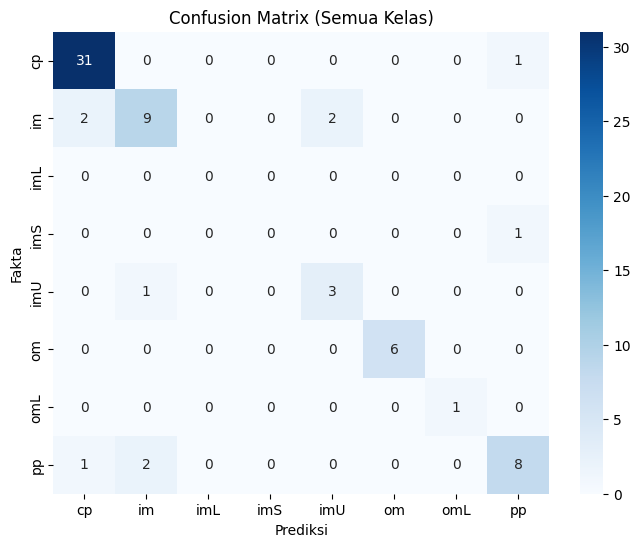

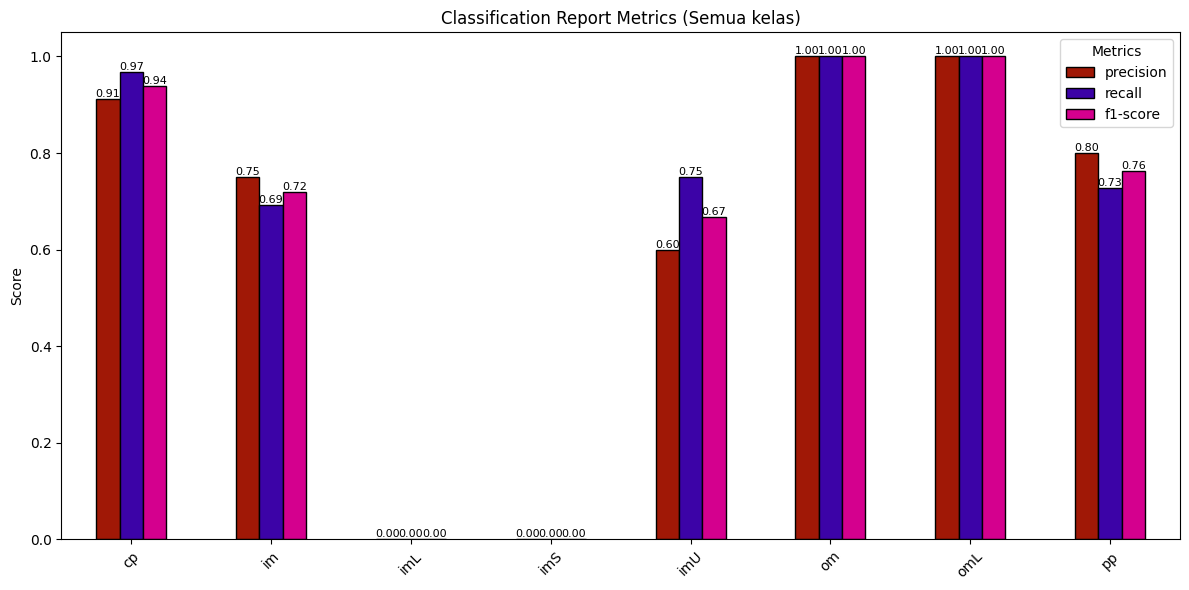

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

prediksi = rf.predict(X_test)

print(f"accuracy_score : {accuracy_score(y_test, prediksi)}")
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train, y_test]))

cm = confusion_matrix(y_test, prediksi, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train, y_test]))

report = classification_report(
    y_test, prediksi, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Hasil Akurasi Klasifikasi Data Ecoli yang Sudah di Oversampling menggunakan SMOTE

accuracy_score : 0.9694323144104804
Classification Report:
               precision    recall  f1-score   support

          cp       0.94      1.00      0.97        32
          im       1.00      0.82      0.90        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        31
         imU       0.84      1.00      0.92        27
          om       1.00      1.00      1.00        29
         omL       1.00      1.00      1.00        19
          pp       1.00      0.94      0.97        34

    accuracy                           0.97       229
   macro avg       0.97      0.97      0.97       229
weighted avg       0.97      0.97      0.97       229



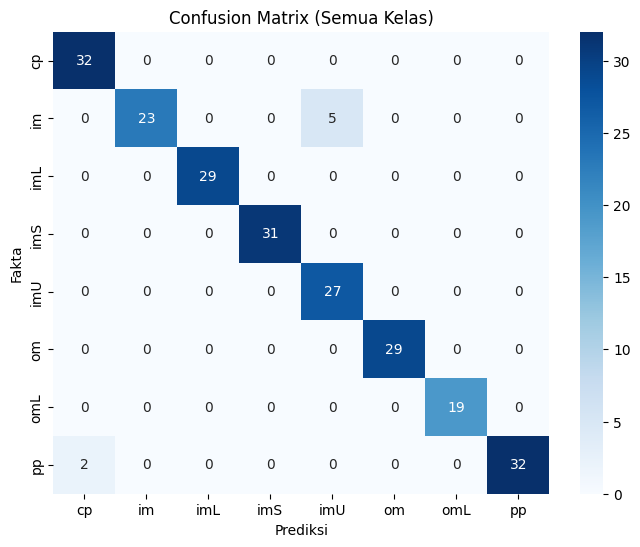

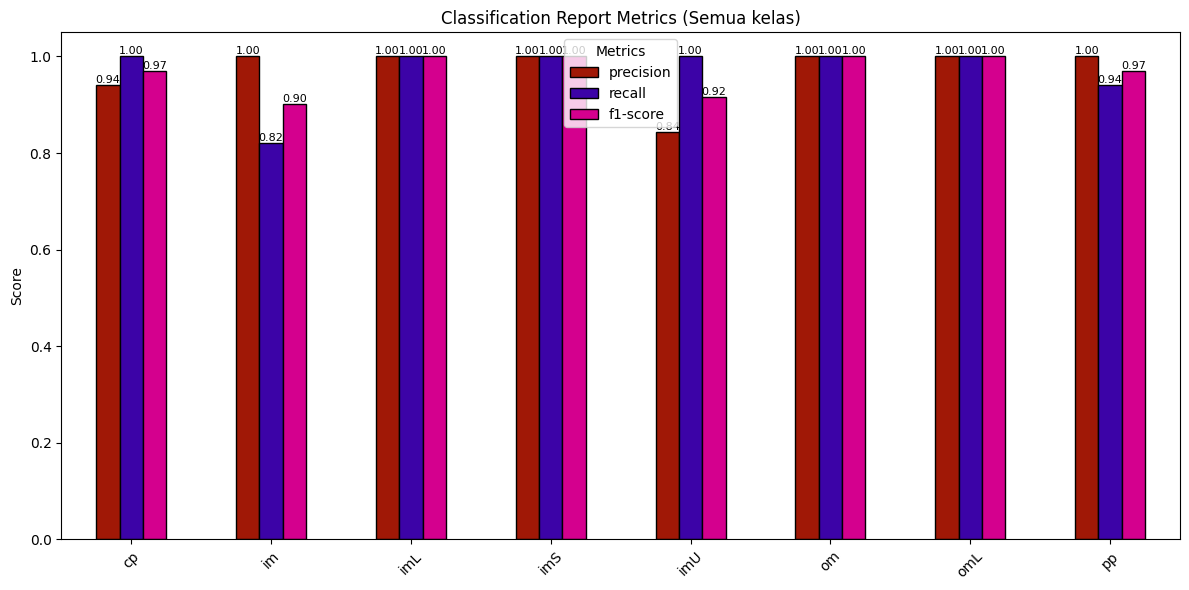

In [6]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

prediksi_smote = rf.predict(X_test_smote)

print(f"accuracy_score : {accuracy_score(y_test_smote, prediksi_smote)}")
print("Classification Report:\n", classification_report(y_test_smote, prediksi_smote, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

report = classification_report(
    y_test_smote, prediksi_smote, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Hasil Akurasi Klasifikasi Data Ecoli yang sudah di Oversampling menggunakan ADASYN

accuracy_score : 0.9695652173913043
Classification Report:
               precision    recall  f1-score   support

          cp       1.00      1.00      1.00        31
          im       0.89      0.86      0.87        28
         imL       1.00      1.00      1.00        26
         imS       1.00      1.00      1.00        29
         imU       0.88      0.90      0.89        31
          om       1.00      1.00      1.00        36
         omL       1.00      1.00      1.00        21
          pp       1.00      1.00      1.00        28

    accuracy                           0.97       230
   macro avg       0.97      0.97      0.97       230
weighted avg       0.97      0.97      0.97       230



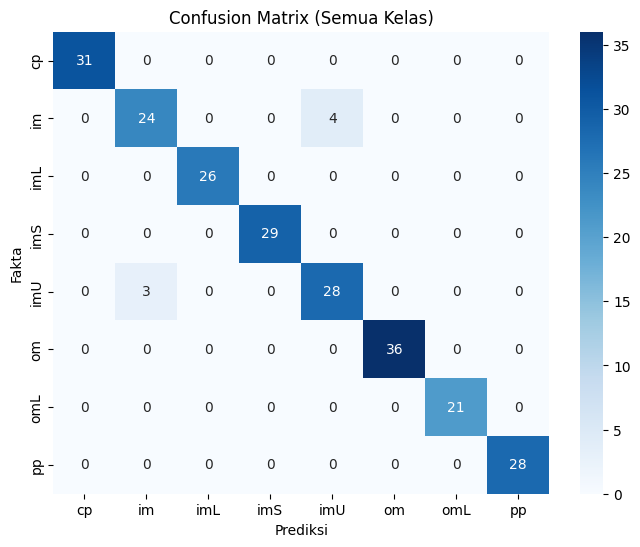

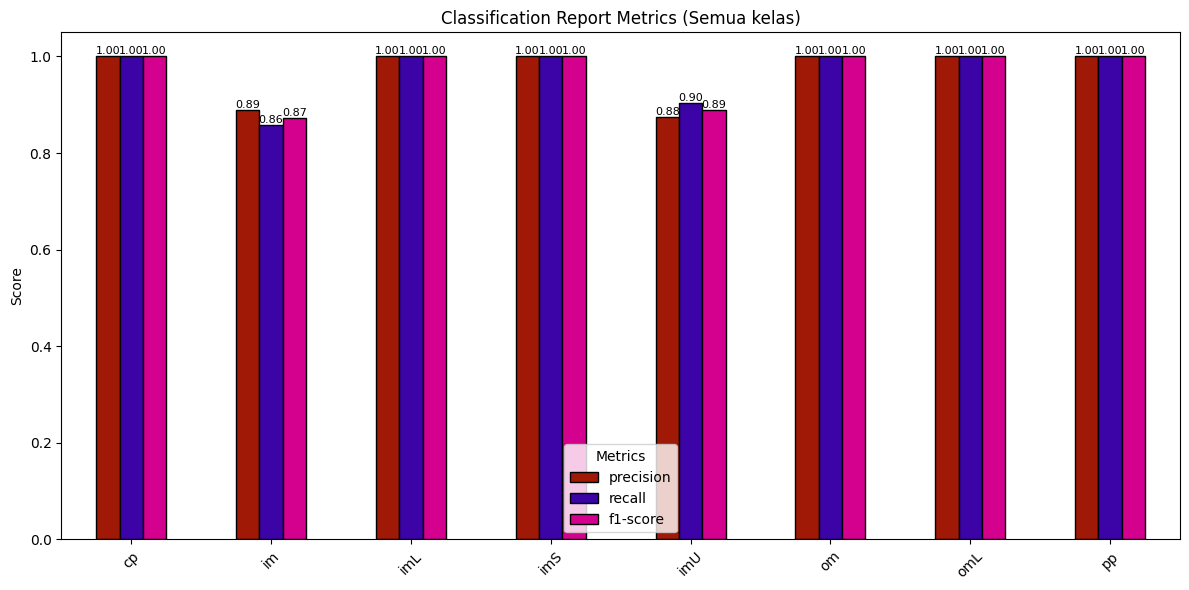

In [7]:
X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_adasyn, y_train_adasyn)

prediksi_adasyn = rf.predict(X_test_adasyn)

print(f"accuracy_score : {accuracy_score(y_test_adasyn, prediksi_adasyn)}")
print("Classification Report:\n", classification_report(y_test_adasyn, prediksi_adasyn, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

report = classification_report(
    y_test_adasyn, prediksi_adasyn, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"],
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Perbandingan akurasi antara data sebelum di oversampling dan sesudah

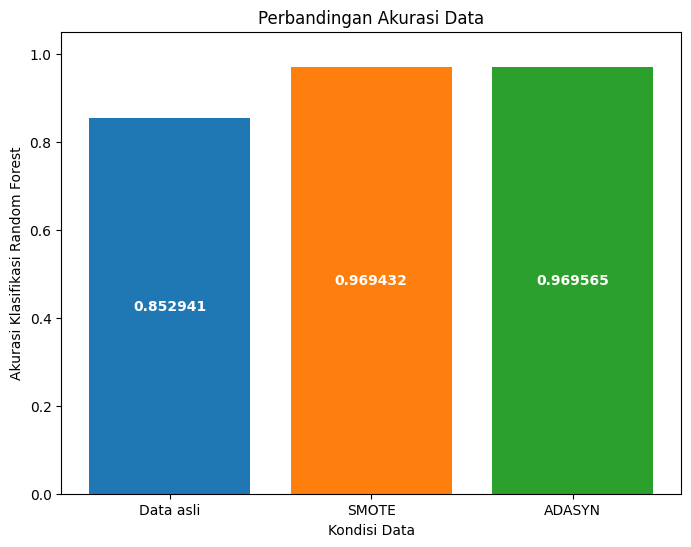

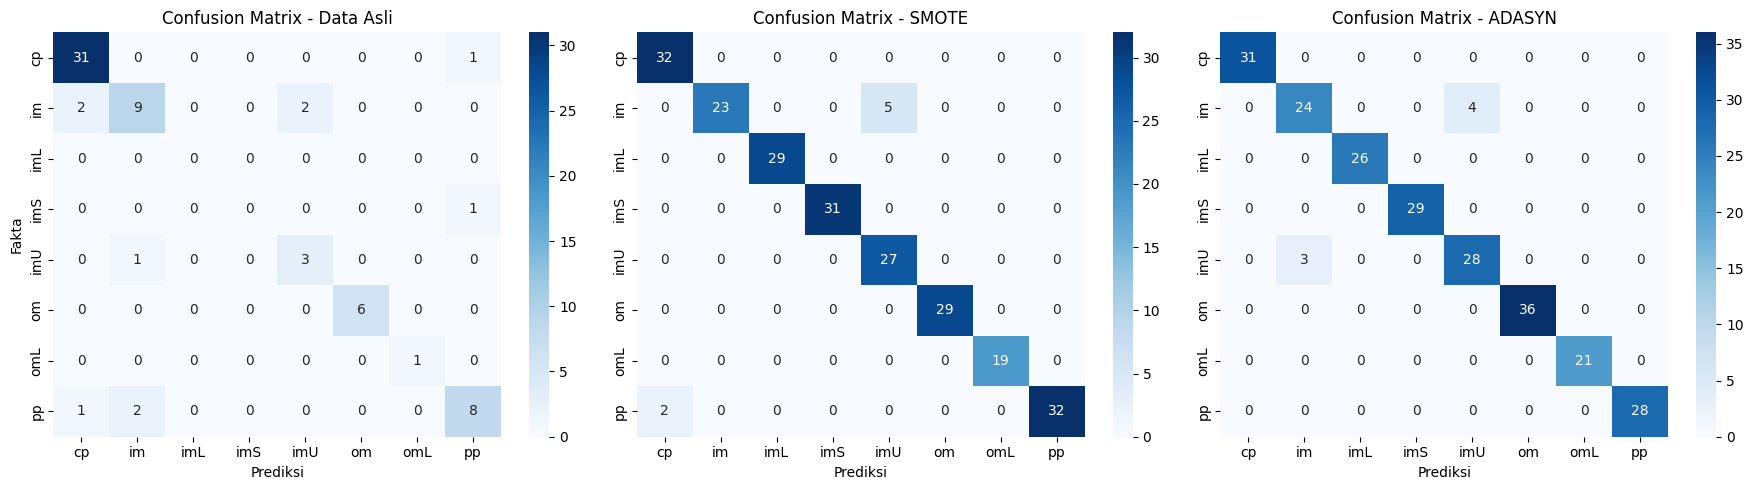

In [8]:
# data yang sebelum di overesampling 

akurasi = accuracy_score(y_test, prediksi)

# data yang sudah di oversampling menggunakan SMOTE

akurasi_smote = accuracy_score(y_test_smote, prediksi_smote)

# data yang sudah di oversampling menggunakan ADASYN

akurasi_adasyn = accuracy_score(y_test_adasyn, prediksi_adasyn)


label = ['Data asli', 'SMOTE', 'ADASYN']
temp = [akurasi, akurasi_smote, akurasi_adasyn]

fig, ax = plt.subplots(figsize=(8,6))

bc = ax.bar(label, temp, color=['#1f77b4','#ff7f0e','#2ca02c'])

ax.bar_label(bc, label_type='center', color='w', fontweight='bold')

ax.set(
    xlabel='Kondisi Data',
    ylabel='Akurasi Klasifikasi Random Forest',
    title='Perbandingan Akurasi Data'
)

ax.set_ylim(0, 1.05)

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data asli
labels = np.unique(np.concatenate([y_train, y_test]))
cm = confusion_matrix(y_test, prediksi, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Data Asli")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Fakta")

# Data SMOTE
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))
cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - SMOTE")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("")

# Data ADASYN
labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))
cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Confusion Matrix - ADASYN")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

Berdasarkan grafik perbandingan akurasi klasifikasi Random Forest, terlihat bahwa pada data asli akurasi hanya mencapai 85,2%, namun setelah dilakukan oversampling dengan SMOTE akurasi meningkat signifikan menjadi 96,9%, dan dengan ADASYN akurasi meningkat lebih tinggi lagi hingga 93,9%. Hal ini menunjukkan bahwa penggunaan teknik oversampling, khususnya SMOTE, mampu memberikan hasil yang lebih baik dibandingkan data asli, sehingga model dapat mengatasi masalah ketidakseimbangan kelas dengan lebih efektif.